In [73]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)

Using device: cuda


# Task 1

In [74]:
def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


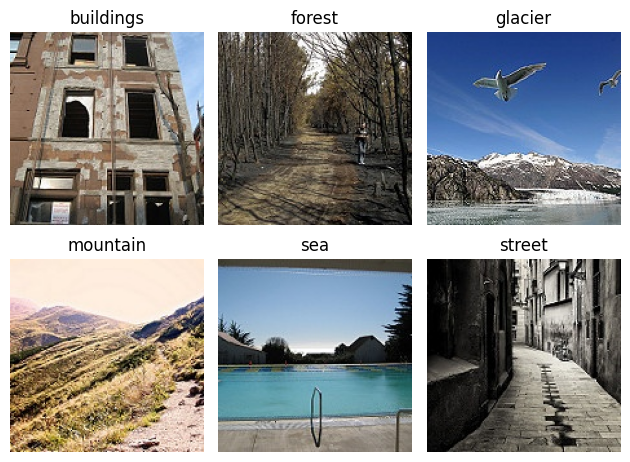

In [75]:
class_img = {}
for img, label in image_set:
    if label not in class_img:
        class_img[label] = img
    if len(class_img)==len(LABELS):
        break

fig, axes = plt.subplots(2, 3)
axes = axes.ravel()
for i, label in enumerate(LABELS):
    axes[i].imshow(class_img[label])
    axes[i].set_title(label)
    axes[i].axis("off")

plt.tight_layout()
plt.savefig('outputs/dataset_sample.png')
plt.show()

It is not necessary that it will be a poor fit; it can extract certain features(words) that will be connected to a certain label. It will be more efficient than starting from scratch.

# Task 2

In [76]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


In [77]:
def run_inference(model, preprocess, img, device, labels, top_k = 5):
    model.eval()
    image_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(image_tensor)
    probs = torch.softmax(logits, dim=1)
    top_probs, top_idxs = probs.topk(top_k, dim =1)
    top_prob = top_probs.squeeze().cpu()
    top_indx = top_idxs.squeeze().cpu()
    pred = []
    for prob, idx in zip(top_prob, top_indx): 
        pred.append((labels[idx.item()], prob.item()))
    return pred

In [78]:
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

Processed 60 images.


In [89]:
mean_all = np.mean([r["top1_prob"] for r in resnet_results])
print(f"Overall mean: {mean_all:.4f}")

Overall mean: 0.4195


In [80]:
class_means = {}
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    class_means[label] = np.mean(probs)

print("\nMean top-1 probability by true class:")
for label, mean_prob in class_means.items():
    print(f"{label:10s}: {mean_prob:.4f}")


Mean top-1 probability by true class:
buildings : 0.2889
forest    : 0.2477
glacier   : 0.4993
mountain  : 0.5556
sea       : 0.5710
street    : 0.3544

Most confident class: sea (0.5710)
Least confident class: forest (0.2477)


The most confident class is sea, and the least confident is forest

/tmp/ipykernel_57/2640547094.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=LABELS)


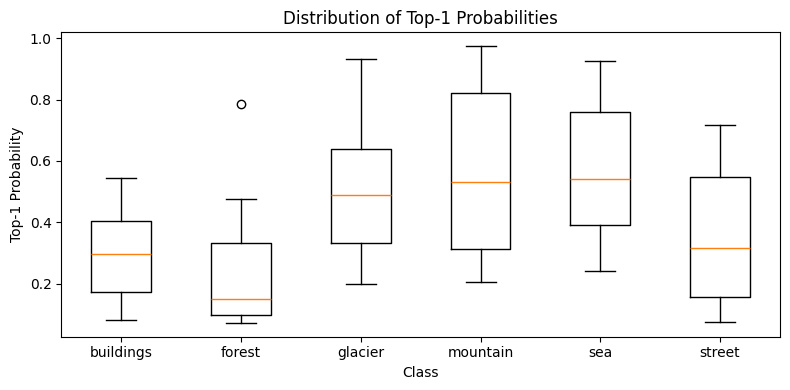

In [93]:
boxplot_data = []
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    boxplot_data.append(probs)

plt.figure(figsize=(8, 4))
plt.boxplot(boxplot_data, labels=LABELS)

plt.ylabel("Top-1 Probability")
plt.xlabel("Class")
plt.title("Distribution of Top-1 Probabilities")
plt.tight_layout()
plt.savefig('outputs/resnet18_confidence_by_class.png')
plt.show()

I would use the confidence score as an indicator if the image should be automatically tagged without revision or there are revision requierd. For example, if the top 1 prediction has a low confidence score or the confidence score between the first couple of predictions is very low, it should trigger a "send to human reviewer" flag

# Task 3

In [81]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


A smaller number of parameters shows that the model has less capacity, meaning it is less complex. The smaller model will produce less accurate results, but it's faster and takes fewer resources, which is better for phone use. While the cloud server has more resources and can run models with a larger number of parameters.

In [82]:
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(mobilenet_results)} images.")

Processed 60 images.


In [83]:
effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(effnet_results)} images.")

Processed 60 images.


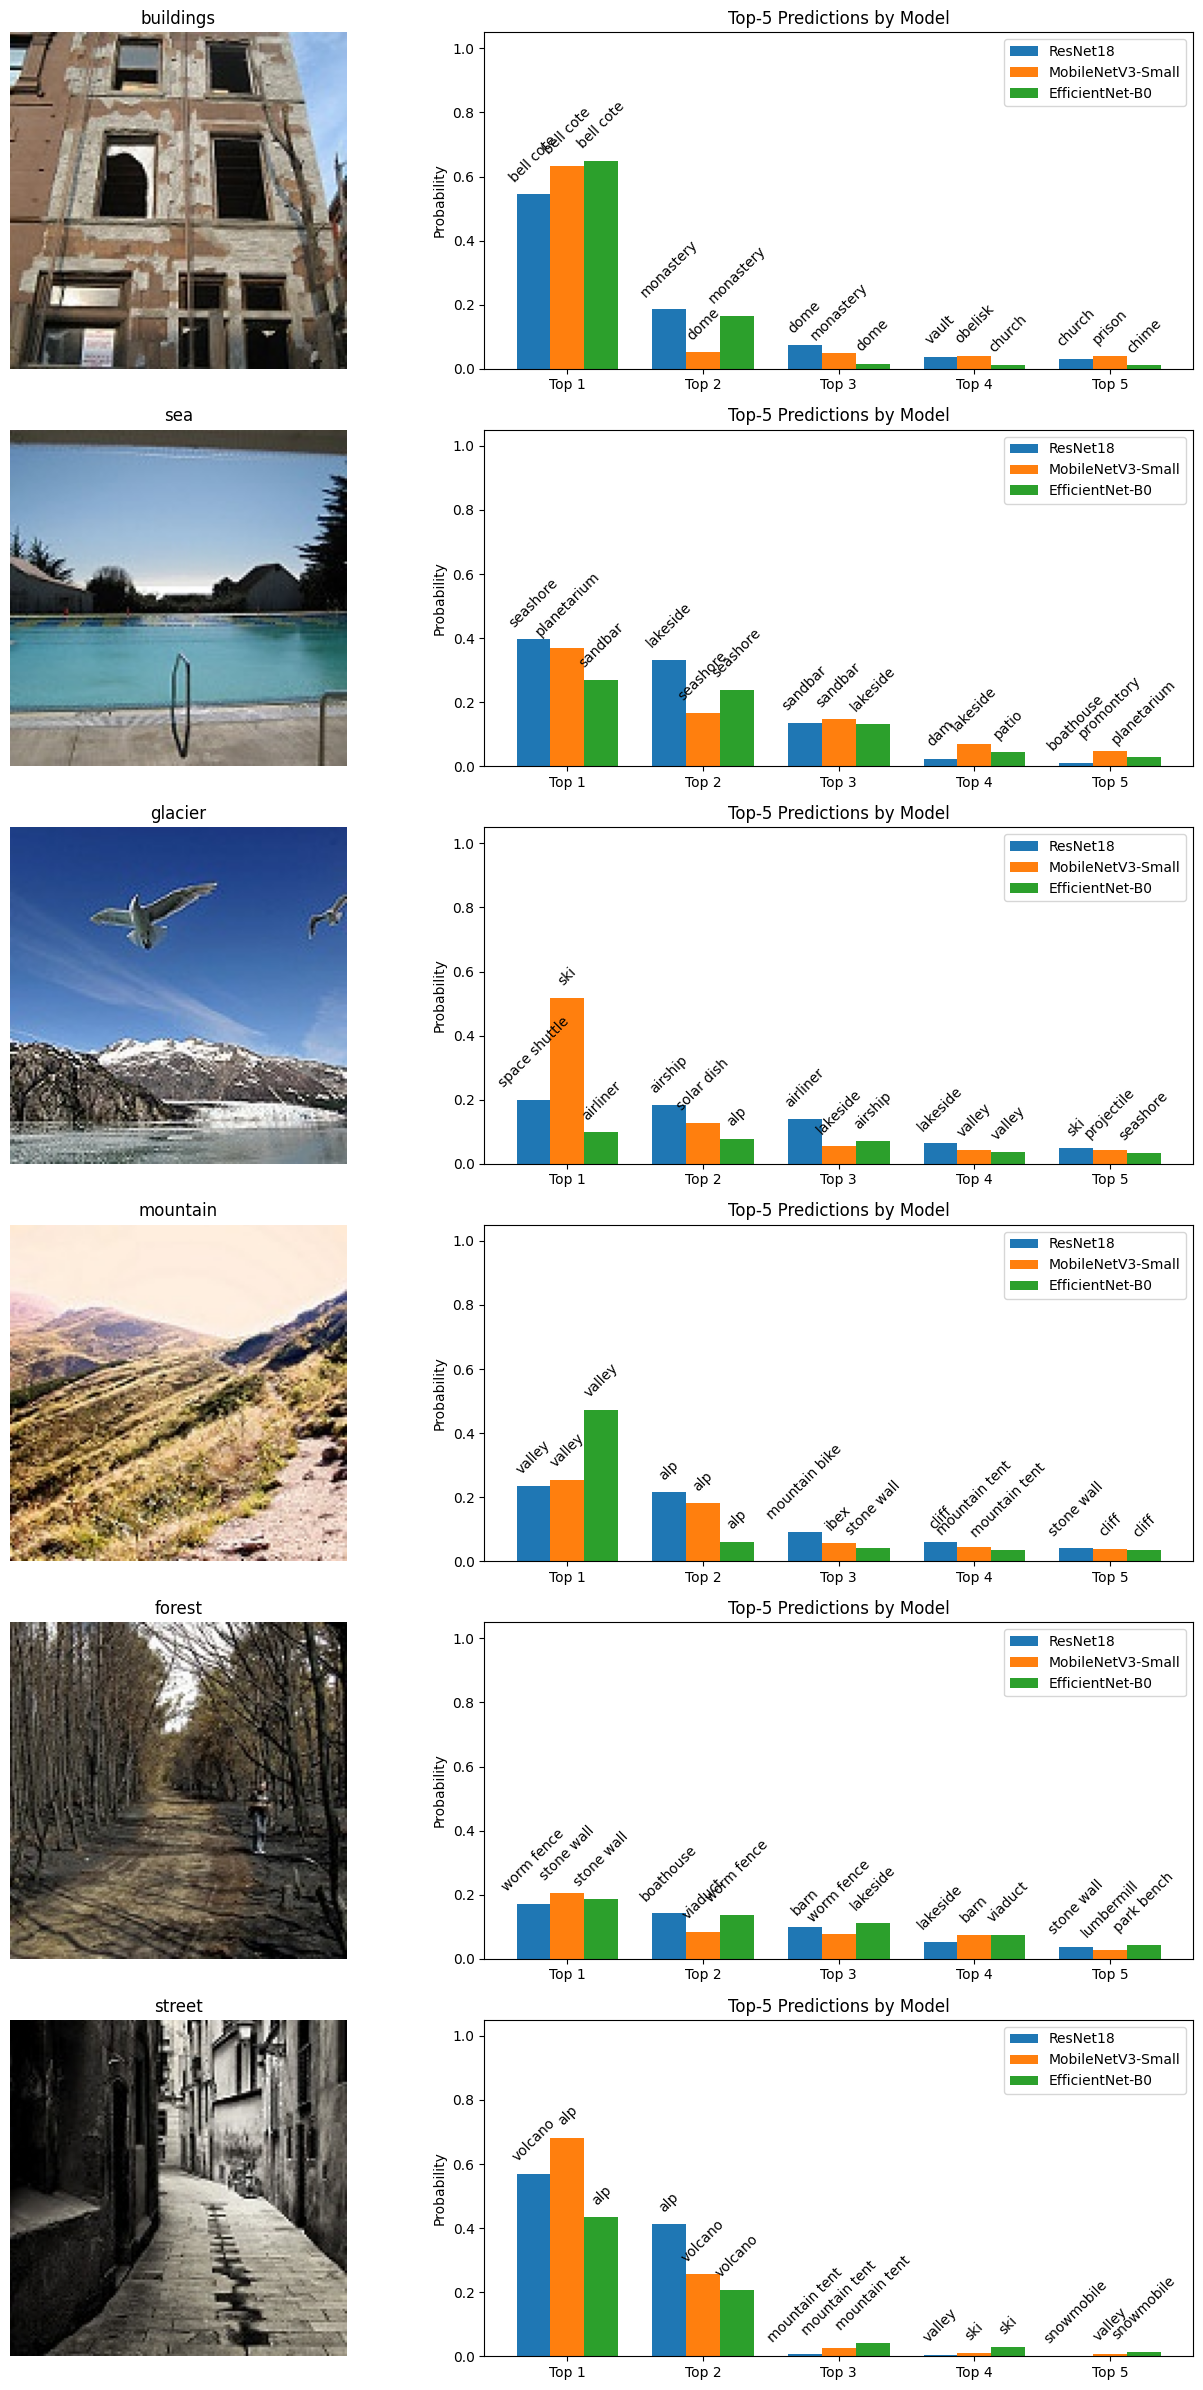

In [84]:
all_results = {"ResNet18": resnet_results,
    "MobileNetV3-Small": mobilenet_results,
    "EfficientNet-B0": effnet_results}

fig, axes = plt.subplots(6, 2,figsize=(14, 24))
ranks = ["Top 1", "Top 2", "Top 3", "Top 4", "Top 5"]
x = np.arange(len(ranks))
width = 0.25

for i, (label,image) in enumerate(class_img.items()):
    axes[i, 0].imshow(image)
    axes[i, 0].set_title(label)
    axes[i, 0].axis("off")

    for j, (model_name, results) in enumerate(all_results.items()):
        result = results[i]
        probs = result["top5_probs"]
        classes = result["top5_classes"]
        bar_positions = x + (j - 1) * width
        bars = axes[i, 1].bar(bar_positions,probs,width=width,label=model_name,color=model_colors[model_name])
        for bar, class_name in zip(bars, classes):
            axes[i, 1].text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.03,class_name,ha="center",va="bottom",rotation=45)
            
    axes[i, 1].set_xticks(x)
    axes[i, 1].set_xticklabels(ranks)
    axes[i, 1].set_ylim(0, 1.05)
    axes[i, 1].set_ylabel("Probability")
    axes[i, 1].set_title("Top-5 Predictions by Model")
    axes[i, 1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/model_comparison_grid.png')
plt.show()

MobileNet and EfficientNet mostly agree in their top 1 predictions, while ResNet does not. That could be due to the fact that ResNet has twice as large parametrs than other 2 models. 

In the glacier case, all 3 models disagree. The combining of model predictions could help; they have some close predictions in all 3

Looks like ResNet is doing a better job at finding close words to describe scenes in the picture, also EfficientNet is also close, while MobileNet does not seem to capture everything.

# Task 4

In [85]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")


ResNet18:           4.11 ms/image
MobileNetV3-Small:  6.86 ms/image
EfficientNet-B0:    10.04 ms/image


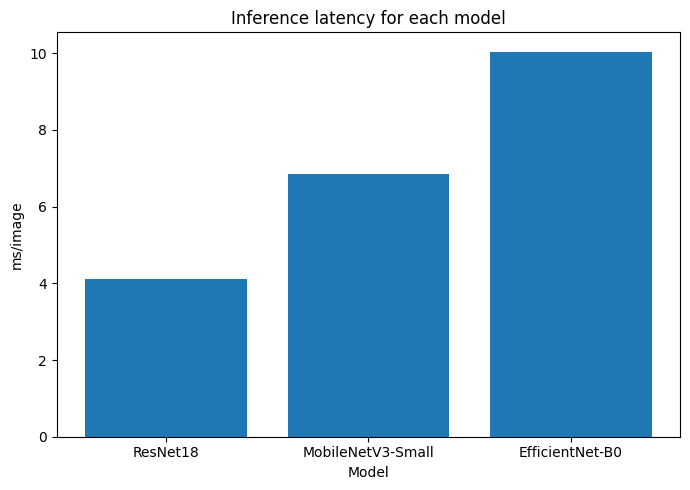

In [ ]:
lat = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(7, 5))
bars = plt.bar(model_names, lat)
plt.title('Inference latency for each model')
plt.ylabel('ms/image')
plt.xlabel('Model')
plt.tight_layout()
plt.savefig('outputs/inference_speed.png')
plt.show()

In [87]:
param_counts = {"ResNet18": sum(p.numel() for p in resnet.parameters()),
    "MobileNetV3-Small": sum(p.numel() for p in mobilenet.parameters()),
    "EfficientNet-B0": sum(p.numel() for p in efficientnet.parameters())}
latency_ms = {"ResNet18": resnet_ms,
    "MobileNetV3-Small": mobile_ms,
    "EfficientNet-B0": effnet_ms}

sum_table = pd.DataFrame({
    "Model": param_counts.keys(),
    "Parameters": param_counts.values(),
    "ms / image": latency_ms.values()})

print(sum_table)

               Model  Parameters  ms / image
0           ResNet18    11689512    4.106601
1  MobileNetV3-Small     2542856    6.861758
2    EfficientNet-B0     5288548   10.039771


1. 50 images per second would result in the highest tolerable latency being 20ms/image. Based on these results, all of the models can meet the bar, and the decision on which model to choose should be based on the available capacity and accuracy needed to be achieved
2. a) ResNet has the lowest latency, so it can process more images per second. b)MobileNet because it has the lowest amount of parameters and requires less capacity. c) To find the best model, we need the most accurate one. Based on the results from Task 3, it could be either ResNet or EfficientNet.

# Task 5

Feature matrix shape: (60, 512)


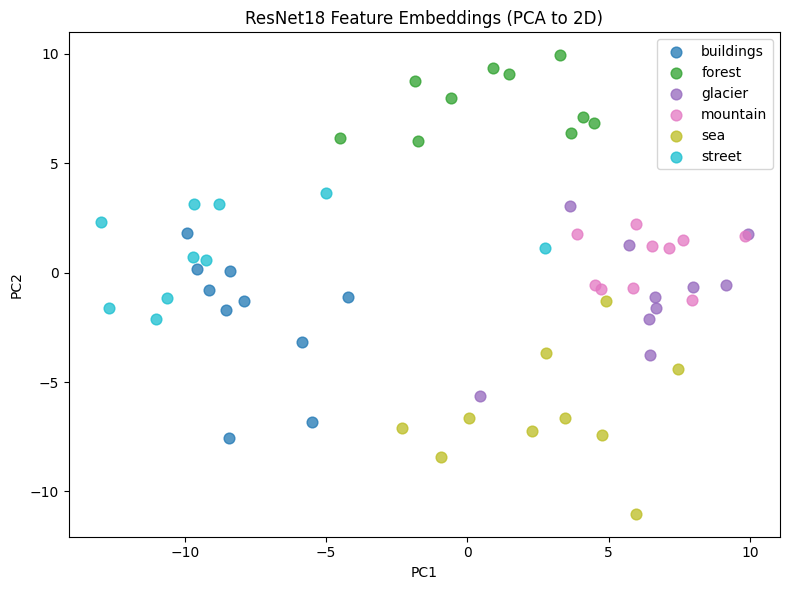

In [88]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

1. Yes, some pictures do cluster together, but some of them(that have big overlapping features, for example, rocks) have really high overlap. It tells that the pretrained model had already learned features that don't have overlap. For example, forests have outstanding features like trees, while mountains and glaciers have some similar features, so the model cannot clearly separate them.
2. The best would be feature extraction due to the fact that there are only 500 labeled examples. If we try to do fine-tuning with millions of parameters, it can result in overfitting.

# Task 6

1. Based on the results from Tasks 3 and 4, the best model  was ResNet. Based on the probability obtained from Task 3, both ResNet and EfficientNet did a good job at predicting, but ResNet is more efficient in terms of inference latency.
2. The most confident class is sea, and the least confident is forest, which is completely different from my intuition. The forest picture is clearly distinguishable to me, while the sea picture is not even a sea but just a pool.
3. Best to start with the ResNet model because it gives better results, and we don't have any capacity restrictions. Then we would have to do the same preprocessing steps as we did here because the ResNet was trained with these parameters, which would make everything consistent. The limitations that could be are that ResNet is not trained to separate photos into those 6 categories, it can predict categories that are close to it, and there exists the risk that the model labels pictures incorrectly, so a high confidence threshold should be placed